In [116]:
#importing the Libraies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [117]:
# Reading the Dataset
dataset = pd.read_csv('50_Startups.csv')

In [118]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [119]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [120]:
dataset=pd.get_dummies(dataset,drop_first=True)

In [121]:
dataset.shape

(50, 6)

In [122]:
indep=dataset[['R&D Spend','Administration', 'Marketing Spend','State_Florida', 'State_New York']]
dep=dataset[['Profit']]

In [123]:
indep

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [124]:
dep = dataset [['Profit']]

In [125]:
dep

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [126]:
#split into training set and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep , dep, test_size = 1/3, random_state = 0)

In [127]:
X_train

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
45,1000.23,124153.04,1903.93,False,True
48,542.05,51743.15,0.00,False,True
29,65605.48,153032.06,107138.38,False,True
15,114523.61,122616.84,261776.23,False,True
30,61994.48,115641.28,91131.24,True,False
32,63408.86,129219.61,46085.25,False,False
16,78013.11,121597.55,264346.06,False,False
42,23640.93,96189.63,148001.11,False,False
20,76253.86,113867.30,298664.47,False,False
43,15505.73,127382.30,35534.17,False,True


In [128]:
y_train

,Profit
45,64926.08
48,35673.41
29,101004.64
15,129917.04
30,99937.59
32,97427.84
16,126992.93
42,71498.49
20,118474.03
43,69758.98


In [129]:
X_test

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
28,66051.52,182645.56,118148.20,True,False
11,100671.96,91790.61,249744.55,False,False
10,101913.08,110594.11,229160.95,True,False
41,27892.92,84710.77,164470.71,True,False
2,153441.51,101145.55,407934.54,True,False
27,72107.60,127864.55,353183.81,False,True
38,20229.59,65947.93,185265.10,False,True
31,61136.38,152701.92,88218.23,False,True
22,73994.56,122782.75,303319.26,True,False
4,142107.34,91391.77,366168.42,True,False


In [130]:
y_test

,Profit
28,103282.38
11,144259.40
10,146121.95
41,77798.83
2,191050.39
27,105008.31
38,81229.06
31,97483.56
22,110352.25
4,166187.94


In [140]:
from sklearn.tree import DecisionTreeRegressor
regressor= DecisionTreeRegressor(criterion="poisson", splitter="random")
regressor=regressor.fit(X_train,y_train)

In [141]:
y_pred=regressor.predict(X_test)

In [142]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [143]:
r_score

0.8847067230771299

In [144]:
regressor.feature_importances_

array([0.92262503, 0.03116171, 0.01253996, 0.00549058, 0.02818273])

In [145]:
regressor.max_features_

5

In [146]:
regressor.tree_

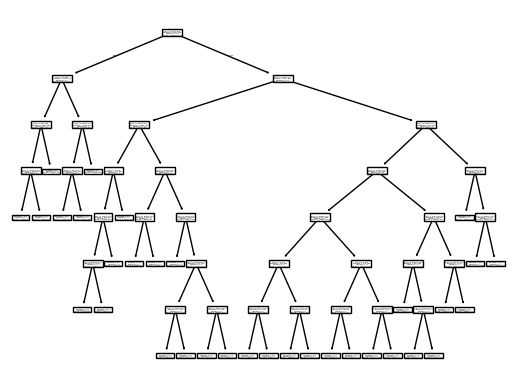

In [147]:
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [148]:
rd_input=float(input("R&D:"))
admin_input=float(input("Admin"))
mark_input=float(input("Marketing "))
fol_input=int(input("State_flo 0 or 1:"))
new_input=int(input("State_new 0 or 1:"))

R&D: 2000
Admin 400
Marketing  4000
State_flo 0 or 1: 0
State_new 0 or 1: 0


In [149]:
result=regressor.predict([[rd_input,admin_input,mark_input,fol_input,new_input]])

C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [150]:
result

array([49490.75])